### Astrostatistic Lecture 19

In [31]:
from astroML.datasets import generate_mu_z
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.linear_model import LinearRegression
from astroML.linear_model import PolynomialRegression
from sklearn.gaussian_process import GaussianProcessRegressor, kernels
from sklearn.gaussian_process.kernels import ConstantKernel, RBF
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy import stats
from sklearn.naive_bayes import GaussianNB
plt.rcParams['figure.facecolor'] = 'black' #custom plot stuff
plt.rcParams['axes.facecolor'] = 'black'
plt.rcParams['axes.edgecolor'] = 'white'         
plt.rcParams['axes.labelcolor'] = 'white'  
plt.rcParams['text.color'] = 'white'  
plt.rcParams['xtick.color'] = 'white'           
plt.rcParams['ytick.color'] = 'white'

data = pd.read_csv('/home/ricca/astrostat/astrostatistics_bicocca_2026/solutions/galaxyquasar.csv') #load data
data

,u,g,r,i,z,class,z1,zerr
0,18.97213,18.53676,18.58280,18.34936,18.29215,QSO,0.522819,0.000155
1,19.24592,17.47646,16.47817,16.04472,15.68851,GALAXY,0.122846,0.000028
2,19.43536,17.70268,16.91565,16.58327,16.39128,GALAXY,0.000000,0.000000
3,19.31626,18.18312,17.39591,16.94549,16.65395,GALAXY,0.147435,0.000009
4,19.28828,19.11188,18.88937,18.80013,18.49183,QSO,2.011455,0.000631
...,...,...,...,...,...,...,...,...
49995,19.37295,18.12382,17.39886,16.98503,16.70585,GALAXY,0.113016,0.000011
49996,18.52021,16.88262,16.03280,15.56884,15.22454,GALAXY,0.085063,0.000014
49997,18.62718,17.30876,16.87371,16.62399,16.42296,GALAXY,0.054429,0.000008
49998,19.55140,18.27711,17.62101,17.21947,17.03347,GALAXY,0.112571,0.000009


In [ ]:
#unpack the data into arrays
z = data['z'].values
u = data['u'].values
g = data['g'].values
r = data['r'].values
i = data['i'].values
z = data['z'].values
cls = data['class'].values
Target=[]
for nome in range(len(cls)):       #for a galaxy 0 quasar 1, target is the correct answer
    if cls[nome] == 'GALAXY':
        Target.append(0)
    else:
        Target.append(1)

#arrays for the color combinations
u_g = u - g
g_r = g - r
r_i = r - i
i_z = i - z

staring_x = np.array([u_g, g_r, r_i, i_z]).T #array for the color combinations (features)

Accuracy score: 0.973900


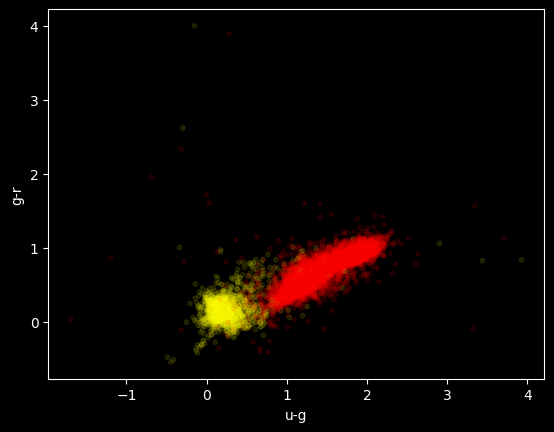

In [40]:
#now we train al algorithm to predict the target, but first we split
#first we use a Gaussian Naive Bayes classifier
X_train, X_test, y_train, y_test = train_test_split(staring_x, Target, test_size=0.2, random_state=42)

gnb = GaussianNB()
gnb.fit(X_train,y_train)

print('Accuracy score: %f' % gnb.score(X_test, y_test))

#try to visualize this 

plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, s=10, cmap='autumn', alpha=0.1)
plt.xlabel('u-g')
plt.ylabel('g-r')
plt.show()

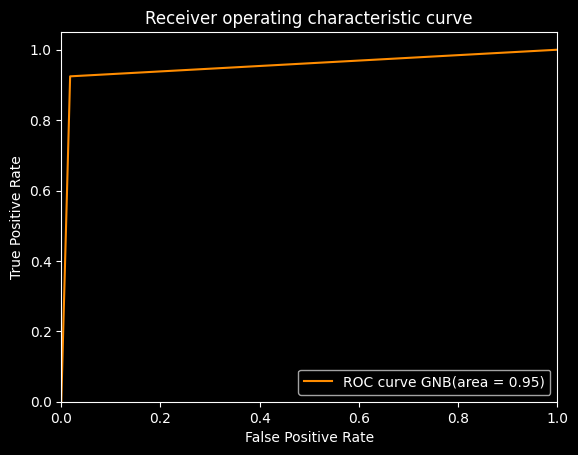

In [36]:
#now evaluate with a ROC curve
fpr, tpr, thresholds = roc_curve(y_test, gnb.predict(X_test))
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', label='ROC curve GNB(area = %0.2f)' % roc_auc)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic curve')
plt.legend(loc="lower right")
plt.show()
